In [1]:
import torch
import torch.nn as nn
import numpy as np
import math
import matplotlib.pyplot as plt
import torch.distributions as D
import os
import csv
from matplotlib.animation import FuncAnimation, PillowWriter

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

<!-- ## GMMs -->

In [3]:
import torch
import torch.distributions as Dist

def _eye(D_, device, dtype):
    return torch.eye(D_, device=device, dtype=dtype)

def create_gaussian_mixture(
    dimension: int,
    num_components: int,
    *,
    eps: float = 1e-5,
    device=None,
    dtype=None,
    means: torch.Tensor | None = None,
    covs:  torch.Tensor | float | None = None,
    weights: torch.Tensor | None = None,
) -> Dist.MixtureSameFamily:
    """
    Build a (batched) Gaussian mixture with safe, explicit shapes.

    Supports:
      means:  [K,D] or [B,K,D]
      covs:
        - scalar -> isotropic for all components (and batches)
        - [K]    -> isotropic per component
        - [K,D]  -> diagonal per component
        - [K,D,D]-> full per component
        - batched versions: [B, ...] matching [B,K,...]
      weights:
        - None -> uniform
        - [K] or [B,K]
    Returns:
      MixtureSameFamily with batch shape [] or [B] and event shape [D].
    """
    if device is None:
        device = means.device if means is not None else torch.device("cpu")
    if dtype is None:
        dtype = means.dtype if means is not None else torch.get_default_dtype()

    # --- Means ---
    if means is None:
        means = 16 * torch.rand(num_components, dimension, device=device, dtype=dtype) - 8
    else:
        means = means.to(device=device, dtype=dtype)

    if means.ndim == 2:
        # single mixture: [K,D]
        B = None
        K, D = means.shape
        assert K == num_components and D == dimension, f"means shape {means.shape} != ({num_components},{dimension})"
    elif means.ndim == 3:
        # batched mixtures: [B,K,D]
        B, K, D = means.shape
        assert K == num_components and D == dimension, f"means shape {means.shape} != (B,{num_components},{dimension})"
    else:
        raise ValueError(f"means must be [K,D] or [B,K,D], got {means.shape}")

    # --- Weights ---
    if weights is None:
        if B is None:
            weights = torch.full((K,), 1.0 / K, device=device, dtype=dtype)
        else:
            weights = torch.full((B, K), 1.0 / K, device=device, dtype=dtype)
    else:
        weights = weights.to(device=device, dtype=dtype)

    # Normalize weights safely
    if B is None:
        assert weights.shape == (K,), f"weights must be [K], got {weights.shape}"
        weights = torch.clamp(weights, min=0)
        weights = weights / weights.sum().clamp_min(1e-12)
    else:
        assert weights.shape == (B, K), f"weights must be [B,K], got {weights.shape}"
        weights = torch.clamp(weights, min=0)
        weights = weights / weights.sum(dim=1, keepdim=True).clamp_min(1e-12)

    # --- Covariances -> covariance_matrix with correct shape ---
    # Target shapes:
    #   single mixture: [K,D,D]
    #   batched:        [B,K,D,D]
    if covs is None:
        if B is None:
            covs_mat = _eye(D, device, dtype).expand(K, D, D).clone()
        else:
            covs_mat = _eye(D, device, dtype).expand(B, K, D, D).clone()
    else:
        covs = torch.as_tensor(covs, device=device, dtype=dtype)
        if covs.ndim == 0:
            # scalar variance
            if B is None:
                covs_mat = covs * _eye(D, device, dtype).expand(K, D, D).clone()
            else:
                covs_mat = covs * _eye(D, device, dtype).expand(B, K, D, D).clone()
        elif covs.ndim == 1:
            # [K] or [B] (we interpret [K] as per-component isotropic)
            if B is None:
                assert covs.shape == (K,), f"covs [K] expected, got {covs.shape}"
                covs_mat = covs.view(K, 1, 1) * _eye(D, device, dtype).view(1, D, D)
            else:
                # If you meant per-component per-batch, pass [B,K] (handled below)
                assert covs.shape == (K,) or covs.shape == (B,), f"covs must be [K] or [B,K]/[B], got {covs.shape}"
                if covs.shape == (K,):
                    covs_mat = covs.view(1, K, 1, 1) * _eye(D, device, dtype).view(1, 1, D, D)
                    covs_mat = covs_mat.expand(B, K, D, D).clone()
                else:
                    # [B] isotropic shared across components
                    covs_mat = covs.view(B, 1, 1, 1) * _eye(D, device, dtype).view(1, 1, D, D)
                    covs_mat = covs_mat.expand(B, K, D, D).clone()
        elif covs.ndim == 2:
            # Could be [K,D] (diag) or [B,K]
            if B is None and covs.shape == (K, D):
                covs_mat = torch.diag_embed(covs)  # [K,D,D]
            elif B is not None and covs.shape == (B, K):
                covs_mat = covs.view(B, K, 1, 1) * _eye(D, device, dtype).view(1, 1, D, D)
            else:
                raise ValueError(f"Ambiguous covs shape {covs.shape}; expected [K,D] or [B,K]")
        elif covs.ndim == 3:
            # [K,D,D] or [B,K,D] (diag per batch/component)
            if B is None and covs.shape == (K, D, D):
                covs_mat = covs
            elif B is not None and covs.shape == (B, K, D):
                covs_mat = torch.diag_embed(covs)  # [B,K,D,D]
            else:
                raise ValueError(f"covs shape {covs.shape} unsupported here")
        elif covs.ndim == 4:
            # [B,K,D,D]
            assert B is not None and covs.shape == (B, K, D, D), f"covs must be [B,K,D,D], got {covs.shape}"
            covs_mat = covs
        else:
            raise ValueError(f"Unsupported covs shape: {covs.shape}")

    # Jitter for PD
    if B is None:
        covs_mat = covs_mat + eps * _eye(D, device, dtype)  # [K,D,D]
    else:
        covs_mat = covs_mat + eps * _eye(D, device, dtype).view(1, 1, D, D)  # [B,K,D,D]

    # --- Build component distribution ---
    if B is None:
        mvn = Dist.MultivariateNormal(loc=means, covariance_matrix=covs_mat)    # batch [K], event [D]
        cat = Dist.Categorical(probs=weights)                                    # batch []
    else:
        # MultivariateNormal supports batch shape [B,K] with loc [B,K,D]
        mvn = Dist.MultivariateNormal(loc=means, covariance_matrix=covs_mat)    # batch [B,K], event [D]
        cat = Dist.Categorical(probs=weights)                                    # batch [B]

    mix = Dist.MixtureSameFamily(cat, mvn)  # event [D]
    return mix


In [4]:
# def create_gaussian_mixture(dimension: int, num_components: int, *,
#                             eps: float = 1e-4, device=device, means=None, covs=None) -> D.MixtureSameFamily:
#     """
#     Create an unconstrained, random Mixture of Gaussians in a given dimension

#     Parameters
#     ----------
#     dimension : int
#         Dimensionality of each component.
#     num_components : int
#         Number of Gaussian components.
#     eps : float, optional
#         Jitter added to the diagonal for numerical stability.
#     device : torch.device or None
#         Move tensors to this device if given.

#     Returns
#     -------
#     torch.distributions.MixtureSameFamily
#     """

#     if means is None:
#         means = 16*torch.rand(num_components, dimension, device=device) - 8
#     else:
#         means = means.to(device)
#         # print(means.shape)
        
#     if (means == 0).all():
#         covs = 2*torch.eye(dimension, device=device)
#     else:
#         if covs is None:
#             covs = 1*torch.eye(dimension, device=device)
#         else:
#             # covs = (1/covs)*torch.eye(dimension, device=device)
#             if covs.ndim == 0:
#                 # scalar variance shared by all components
#                 covs = covs.expand(num_components)
#             if covs.ndim == 1:
#                 # (K,) → isotropic diag per component
#                 covs = covs.view(covs.shape[0], 1, 1, 1)* torch.eye(dimension, device=device).view(1, 1, dimension, dimension)
#                 covs = covs.expand(covs.shape[0], num_components, dimension, dimension)
#                 # print(covs.shape)
#             elif covs.ndim == 2:
#                 # (K, dim) → diagonal per component
#                 covs = torch.diag_embed(covs)
#             elif covs.ndim == 3:
#                 # (K, dim, dim) → full cov, keep as is
#                 pass
#             else:
#                 raise ValueError(f"Unsupported covs shape: {covs.shape}")
    

#     # Mixture weights  (K,)
#     if len(means.shape) == 2:
#         weights = torch.ones(num_components, device=device)
#         weights.div_(weights.sum())
#     else:
#         batch_size = means.shape[0]
#         weights = torch.ones(batch_size, num_components, device=device)
#         weights.div_(weights.sum(dim=1, keepdim=True))

#     # Build the distribution
#     # print(means.shape, covs.shape)

#     mvn = D.MultivariateNormal(loc=means, covariance_matrix=covs)
#     mix = D.MixtureSameFamily(
#         mixture_distribution=D.Categorical(probs=weights),
#         component_distribution=mvn,
#     )
#     return mix

In [5]:
means_40 = torch.tensor([
            [-0.2995,  21.4577],
            [-32.9218, -29.4376],
            [-15.4062,  10.7263],
            [ -0.7925,  31.7156],
            [ -3.5498,  10.5845],
            [-12.0885,  -7.8626],
            [-38.2139, -26.4913],
            [-16.4889,   1.4817],
            [ 15.8134,  24.0009],
            [-27.1176, -17.4185],
            [ 14.5287,  33.2155],
            [ -8.2320,  29.9325],
            [ -6.4473,   4.2326],
            [ 36.2190, -37.1068],
            [-25.1815, -10.1266],
            [-15.5920,  34.5600],
            [-25.9272, -18.4133],
            [-27.9456, -37.4624],
            [-23.3496,  34.3839],
            [ 17.8487,  19.3869],
            [  2.1037, -20.5073],
            [  6.7674, -37.3478],
            [-28.9026, -20.6212],
            [ 25.2375,  23.4529],
            [-17.7398,  -1.4433],
            [ 25.5824,  39.7653],
            [ 15.8753,   5.4037],
            [ 26.8195, -23.5521],
            [  7.4538, -31.0122],
            [-27.7234, -20.6633],
            [ 18.0989,  16.0864],
            [-23.6941,  12.0843],
            [ 21.9589,  -5.0487],
            [  1.5273,   9.2682],
            [ 24.8151,  38.4078],
            [-30.8249, -14.6588],
            [ 15.7204,  33.1420],
            [ 34.8083,  35.2943],
            [  7.9606, -34.7883],
            [  3.6797, -25.0242],
                                ], device=device)

<!-- ## 2D GMMs -->

<!-- ## Sampling using Langevin Dynamics -->

In [6]:
torch.manual_seed(42)

<!-- ## NETS Neural Network Implementation -->

In [7]:
class DriftNet(nn.Module):
    def __init__(self, dim):
        super().__init__()
        if dim == 2:
            self.net = nn.Sequential(
            nn.Linear(dim + 1, 256),
            nn.Tanh(),
            nn.Linear(256, dim)
        )
        else:
            self.net = nn.Sequential(
                nn.Linear(dim + 1, 512),
                nn.Tanh(),
                nn.Linear(512, 512),
                nn.Tanh(),
                nn.Linear(512, 512),
                nn.Tanh(),
                nn.Linear(512, 512),
                nn.Tanh(),
                nn.Linear(512, dim)
            )
        
    def forward(self, x, t):
        t = t.unsqueeze(-1) if t.ndim == 1 else t
        xt = torch.cat([x, t], dim=-1)
        return self.net(xt)

class FreeEnergyNet(nn.Module):
    def __init__(self, dim):
        super().__init__()
        if dim == 2:
            self.net = nn.Sequential(
            nn.Linear(1, 256),
            nn.Tanh(),
            nn.Linear(256, 1)
        )
        else:
            self.net = nn.Sequential(
                nn.Linear(1, 512),
                nn.Tanh(),
                nn.Linear(512, 512),
                nn.Tanh(),
                nn.Linear(512, 512),
                nn.Tanh(),
                nn.Linear(512, 512),
                nn.Tanh(),
                nn.Linear(512, 1)
            )
    def forward(self, t):
        t = t.unsqueeze(-1) if t.ndim == 1 else t
        return self.net(t).squeeze(-1)

class PotentialNet(nn.Module):
    def __init__(self, dim):
        super().__init__()
        if dim == 2:
            self.net = nn.Sequential(
            nn.Linear(dim + 1, 256),
            nn.Tanh(),
            nn.Linear(256, 1)
        )
        else:
            self.net = nn.Sequential(
                nn.Linear(dim + 1, 512),
                nn.Tanh(),
                nn.Linear(512, 512),
                nn.Tanh(),
                nn.Linear(512, 512),
                nn.Tanh(),
                nn.Linear(512, 512),
                nn.Tanh(),
                nn.Linear(512, 1)
            )

    def forward(self, x, t):
        t = t.unsqueeze(-1) if t.ndim == 1 else t
        xt = torch.cat([x, t], dim=-1)
        return self.net(xt).squeeze(-1) 

<!-- ## Potentials -->

In [8]:
def target_U(x, mixture):
    return -mixture.log_prob(x).unsqueeze(-1)

def U_gmm_means(x, t, means):
    """
    x:      [N, D]
    t:      [N] or scalar
    means:  [C, D]
    beta(t): precision schedule (1/variance)
    returns U_t(x): [N, 1]
    """
    device = x.device
    N, D = x.shape
    C = means.shape[0]

    if torch.is_tensor(t):
        t = t.view(-1, 1, 1).to(device)
    else:
        t = torch.tensor(t, device=device, dtype=x.dtype).view(1, 1, 1)

    means_ = means[None, :, :]                       # [1,C,D]
    diff2 = (x[:, None, :] - t * means_).pow(2).sum(dim=-1)  # [N,C]
    energy = 0.5 * diff2  # [N,C]
    log_norm = -0.5 * D * math.log(2 * math.pi) 
    # ---- log-sum-exp mixture + normalization
    logp =  - math.log(C) + log_norm + torch.logsumexp(-energy, dim=1) # [N]
    Ut = -logp.unsqueeze(-1)                                       # [N,1]
    return Ut

def beta_schedule(t, beta_max=32, beta_min=1):
    return beta_max + (beta_min - beta_max) * t

def U_gmm_modes(x, t, modes):
    """
    x:      [N, D]
    t:      [N] or scalar
    means:  [C, D]
    beta(t): precision schedule (1/variance)
    returns U_t(x): [N, 1]
    """
    device = x.device
    N, D = x.shape
    C = modes.shape[0]
    beta = beta_schedule(t)

    means_ = modes[None, :, :]                       # [1,C,D]
    # beta = torch.full((1,), beta, device=device).requires_grad_(True)
    diff2 = (x[:, None, :] - means_).pow(2).sum(dim=-1)  # [N,C]
    energy = 0.5 * beta[:, None] * diff2  # [N,C]
    log_norm = 0.5 * D * (torch.log(beta) - math.log(2 * math.pi)) # [N]
    # ---- log-sum-exp mixture + normalization
    # print(torch.logsumexp(-energy, dim=1))
    logp =  - math.log(C) + log_norm + torch.logsumexp(-energy, dim=1) # [N]
    Ut = -logp.unsqueeze(-1)                                       # [N,1]
    return Ut, beta


def U_t(x, t, means, U_net, modes, mixture):
    if means is not None:
        Ut = U_gmm_means(x, t, means)
    elif modes is not None:
        beta = beta_schedule(t)
        U_gmm_t, beta = U_gmm_modes(x, t, modes)
        U1 = target_U(x, mixture)
        Ut = U1 + U_gmm_t
    else:
        U0 = 0.5 * (x ** 2).sum(dim=1)
        U1 = target_U(x, mixture)
        if U_net is not None:
            U_theta = U_net(x, t)
            Ut = (1 - t) * U0 + t * U1 + t * (1 - t) * U_theta
        else:
            Ut = (1 - t) * U0 + t * U1
    return Ut


def grad_U_t(x, t, means, U_net, modes, mixture):
    # U, _ = U_t(x, t, means, U_net)
    U = U_t(x, t, means, U_net, modes, mixture)
    grad = torch.autograd.grad(U.sum(), x, create_graph=False)[0]
    return grad

def partial_t_U(x, t, means, U_net, modes, mixture):
    # U, Ut_Ft = U_t(x, t, means, U_net)
    U = U_t(x, t, means, U_net, modes, mixture)
    partial_t = torch.autograd.grad(U.sum(), t, create_graph=False)[0]
    # partial_t_F = torch.autograd.grad(Ut_Ft.sum(), t, create_graph=True)[0]
    return partial_t

In [9]:
def divergence(y, x):
    noise = torch.randn_like(x)
    grad_y = torch.autograd.grad(
        y, x, grad_outputs=noise, create_graph=True, retain_graph=True)[0]
    return (grad_y * noise).sum(dim=1)

In [10]:
def ess_eval(A_trajectory):
    a_max, _ = A_trajectory.max(dim=1, keepdim=True)
    w = torch.exp(A_trajectory - a_max)
    ess = (w.mean(dim=-1) ** 2) / (w ** 2 + 1e-12).mean(dim=-1)
    return ess

In [11]:
@torch.inference_mode
def p_t(x, t, means, U_net, modes, mixture):
    density = torch.exp(-U_t(x, t, means, U_net, modes, mixture))
    return density

@torch.inference_mode
def plot_walkers(x, t, means, U_net, step, modes, mixture):
    device = x.device
    with torch.no_grad():                        # no grad tracking
        pts = x.cpu().numpy()           # (n_walkers, dim)
    if len(modes) == 40:
        size = 40
    else: 
        size = 20
    plt.figure(figsize=(5, 5))
    xlin = torch.linspace(-size, size, 500, device=device)
    ylin = torch.linspace(-size, size, 500, device=device)
    X, Y = torch.meshgrid(xlin, ylin, indexing='xy')
    grid = torch.stack([X.flatten(), Y.flatten()], dim=-1)
    plt.scatter(pts[:, 0], pts[:, 1], s=10, color='grey', alpha=1)
    # plt.scatter(modes[:, 0], modes[:, 1], marker='x', s=30)
    t_tensor = torch.full((grid.shape[0],), t, device=device)
    p_vals = p_t(grid, t_tensor, means, U_net, modes, mixture).reshape(500, 500)
    plt.contour(X.cpu().numpy(), Y.cpu().numpy(), p_vals.cpu().numpy(), levels=10, cmap='summer', alpha=0.6)
    plt.title(f"Walker positions – step {step}")
    plt.xlabel("$x_1$");  plt.ylabel("$x_2$")
    plt.xlim([-size, size]);    
    plt.ylim([-size, size])      # tweak if needed
    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [12]:
torch.manual_seed(40)

epsilon = 1
n_steps = 250
T = 1
dt = T / n_steps
# grid, dt = build_time_grid(n_steps, T)
num_samples = 2000
means = None
U_net = None
modes = not None
dim = 2
num_components = 4
mixture = create_gaussian_mixture(dim, num_components, means=means_40, device=device)
true_modes = mixture.component_distribution.mean
modes = true_modes + 4*torch.randn(num_components, dim).to(device)
# modes = true_modes
load_dir = f'/Users/dilumfernando/projects/NETs/alps_interpolation/{dim}d_{num_components}gmm'

AssertionError: means shape torch.Size([40, 2]) != (4,2)

In [ ]:
def langevin_sampler(x0, A0, dt, steps, epsilon, means, U_net, modes, mixture):
    x = x0.detach().requires_grad_(True)
    A = A0
    x_trajectory = [x0.detach().cpu()] 
    A_trajectory = [A.cpu()]

    for step in range(steps):
        if step % 10 == 0:
            plot_walkers(x, dt * step, means, U_net, step, modes, mixture)
        # dt = dt[step]
        t_tensor = torch.full((x.shape[0],), step * dt, device=device).requires_grad_(True)

        grad_U = grad_U_t(x, t_tensor, means, U_net, modes, mixture) 
        # print(grad_U)
        dtU = partial_t_U(x, t_tensor, means, U_net, modes, mixture)
        noise = torch.randn_like(x)
        x = x - epsilon * grad_U * dt + torch.sqrt(torch.tensor(2 * epsilon * dt)) * noise
        A = A - dtU * dt

        x_trajectory.append(x.detach().cpu())
        A_trajectory.append(A.detach().cpu())
        x = x.detach().requires_grad_(True)
        # print(A)
    return torch.stack(x_trajectory), torch.stack(A_trajectory)  # (steps, batch, 2)
# torch.autograd.set_detect_anomaly(True)

means_ = modes
K, dim = means_.shape
beta_max = torch.tensor(1e2, device=device).unsqueeze(0).expand(num_samples)         
means_prior = means_.unsqueeze(0).expand(num_samples, -1, -1) 
mix = create_gaussian_mixture(dim, K, means=means_prior.to(device), covs=1/beta_max)
x0 = mix.sample().to(device)
# x0 = torch.randn(num_samples, dim, device=device)

A0 = torch.zeros(num_samples, device=device)
x_langevin, A_langevin = langevin_sampler(x0, A0, dt = dt, steps=n_steps, 
                                          epsilon=epsilon, means=means, U_net=U_net, 
                                          modes=true_modes, mixture=mixture)
ess_langevin = ess_eval(A_langevin)
print(ess_langevin)

In [13]:
def plot_annealed_langevin(means):
    # 6. Set up plot and animation
    device = means.device
    modes = means
    means = None
    size = 40
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(-size, size)
    ax.set_ylim(-size, size)
    ax.set_aspect('equal')
    ax.set_title("Annealed Langevin Dynamics")
    ax.grid(True)

    # Create a 2D grid
    x = torch.linspace(-size, size, 500, device=device)
    y = torch.linspace(-size, size, 500, device=device)
    X, Y = torch.meshgrid(x, y, indexing='xy')
    grid = torch.stack([X.flatten(), Y.flatten()], dim=-1)

    # Precompute contour levels once (fix levels for stability)
    levels = 10

    def update(frame):
        ax.clear()
        t_tensor = torch.full((grid.shape[0],), frame*dt, device=grid.device)
        p_vals = p_t(grid, t_tensor, means, U_net, modes, mixture).reshape(500, 500)
        ax.contour(X.cpu().numpy(), Y.cpu().numpy(), p_vals.detach().cpu().numpy(), levels=levels, cmap='summer', alpha=0.5)
        ax.scatter(x_langevin[frame][:, 0].cpu(), x_langevin[frame][:, 1].cpu(),
                s=10, color='grey', alpha=0.2)
        ax.set_xlim(-size, size)
        ax.set_ylim(-size, size) 
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title(f"Annealed Langevin Dynamics, time={t_tensor[0] + dt:.2f}")


    anim = FuncAnimation(fig, update, frames=n_steps, interval=100)

    # To save as GIF uncomment:
    gif_path = os.path.join(load_dir, 'ALD_modes_eps1.gif')
    # gif_path = os.path.join(load_dir, 'density.gif')
    anim.save(gif_path, writer=PillowWriter(fps=60))

    plt.show()

KeyboardInterrupt: 

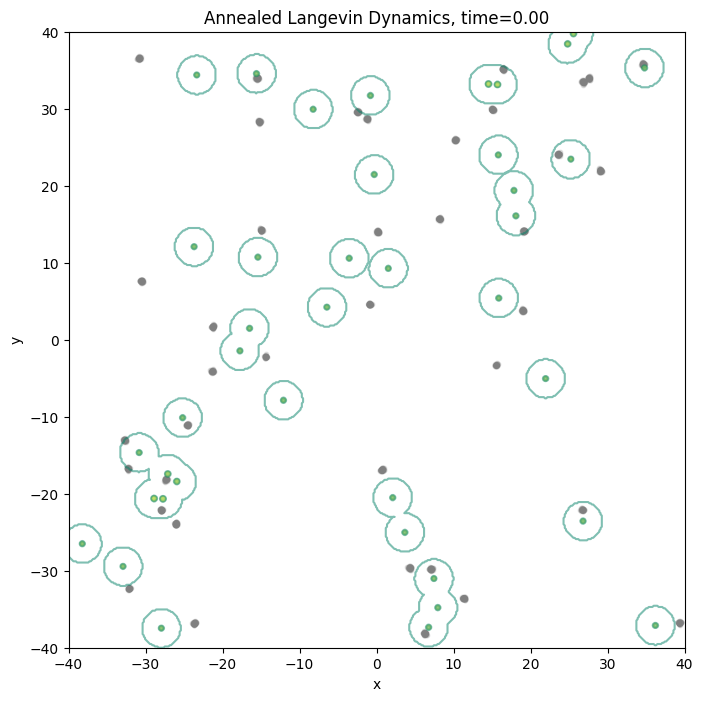

In [398]:
plot_annealed_langevin(true_modes)

<!-- ## Training and Saving -->

In [15]:
def train_step(drift_net, F_net, U_net, epsilon, mixture, step, steps, dim=2, 
               n_walkers=1000, K=50, T=1.0, plot_every=100, means=None, modes=None, 
               prior=None):
    # torch.manual_seed(40)
    device = next(drift_net.parameters()).device
    x = prior

    A = torch.zeros(n_walkers, device=device)

    # annealing the time T for training
    T_max = 1.0
    T_min = 0.05
    gamma = 1 # gamma = 1 for linear ramp and gamma > 1 for slower starts and faster ends and gamma < 1 for faster growth and slower ends
    current_T = T_min + (T_max - T_min) * (step / steps) ** gamma
    # current_T = 1.0
    time_grid = torch.sort(torch.rand(K + 1, device=device) * current_T)[0]


    delta_ts = time_grid[1:] - time_grid[:-1]
    total_loss = 0
    total_F_diff = 0
    for k in range(K):
        t_k = time_grid[k].expand(n_walkers).detach().requires_grad_(True)
        delta_t = delta_ts[k]

        b = drift_net(x, t_k)
        gradU = grad_U_t(x, t_k, means, U_net, modes, mixture)
        div_b = divergence(b, x)
        dtU = partial_t_U(x, t_k, means, U_net, modes, mixture)
        # print(dtU)
        

        # Langevin update
        noise = torch.randn_like(x)
        x_next = x - epsilon * gradU * delta_t + b * delta_t + ((2 * epsilon * delta_t) ** 0.5) * noise

        # Update A
        A = A + div_b * delta_t  - (b * gradU).sum(dim=1) * delta_t - dtU * delta_t
        
        # Evaluate PINN loss
        x_det = x.detach().requires_grad_(True)
        t_det = t_k.detach().requires_grad_(True)

        b_eval = drift_net(x_det, t_det)
        gradU_eval = grad_U_t(x_det, t_det, means, U_net, modes, mixture)
        div_b_eval = divergence(b_eval, x_det)
        dtU_eval = partial_t_U(x_det, t_det, means, U_net, modes, mixture)
        dF_dt = torch.autograd.grad(F_net(t_det).sum(),
                                    t_det, create_graph=True)[0]

        # Free energy difference calculations
        # F_diff = (partial_t_F.mean() - dF_dt.mean()) ** 2 

        err = div_b_eval - (gradU_eval * b_eval).sum(dim=1) - dtU_eval + dF_dt
        logw = A
        weights = torch.exp(logw - logw.max())
        # weights = torch.exp(A)

        eps = 1e-15
        loss = (weights * err**2).sum() / (weights.sum() + eps)

        total_loss = total_loss + delta_t * loss
        # total_F_diff = total_F_diff + delta_t * F_diff

        x = x_next.detach().requires_grad_(True)  # Detach walker paths (off-policy)

    if step % plot_every == 0 and dim == 2:
        plot_walkers(x, current_T, means, U_net, step, modes, mixture)
    # return total_loss, weights, err, total_F_diff
    return total_loss, weights, err, _

In [16]:
def ess_from_logw(logw, eps=1e-10):
    """
    Numerically stable ESS from log-weights.

    logw: [N] tensor of log-weights
    """
    # subtract max for stability before exponentiating
    logw = logw - logw.max()
    w = torch.exp(logw)
    mean_w = w.mean()
    mean_w2 = (w ** 2).mean()
    return (mean_w ** 2) / (mean_w2 + eps)

def ess_eval(A_trajectory, eps=1e-10):
    """
    Compute ESS for each timestep of log-weight trajectories.
    A_trajectory: [T, N] tensor of log-weights.
    """
    ess_vals = []
    for t in range(A_trajectory.shape[0]):
        ess_vals.append(ess_from_logw(A_trajectory[t], eps))
    return torch.stack(ess_vals)

In [22]:
def train_and_save(dim, num_components, mixture, means=None, U_net=None, modes=None, device=device, prior=None):
    # initialize training hyper-parameters
    n_walkers = 1000
    steps = 1000
    epsilon = 0
    K = 50

    # initialize models and the optimizer
    drift_net = DriftNet(dim).to(device)
    F_net  = FreeEnergyNet(dim).to(device)

    if U_net is not None:
        save_dir = f'/Users/dilumfernando/projects/NETs/learned_interpolation/{dim}d_{num_components}gmm'
        U_net = PotentialNet(dim).to(device)
        optimizer = torch.optim.Adam(list(drift_net.parameters()) + list(F_net.parameters()) + list(U_net.parameters()), lr=1e-4)
        print('using the potential network')
    elif means is not None:
        save_dir = f'/Users/dilumfernando/projects/NETs/mean_interpolation/{dim}d_{num_components}gmm'
        optimizer = torch.optim.Adam(list(drift_net.parameters()) + list(F_net.parameters()), lr=1e-4)
        print('using the mean interpolation')
    elif modes is not None:
        save_dir = f'/Users/dilumfernando/projects/NETs/alps_interpolation/{dim}d_{num_components}gmm'
        optimizer = torch.optim.Adam(list(drift_net.parameters()) + list(F_net.parameters()), lr=1e-4)
        print('using the alps interpolation')
    else:
        save_dir = f'/Users/dilumfernando/projects/NETs/fixed_interpolation/{dim}d_{num_components}gmm'
        optimizer = torch.optim.Adam(list(drift_net.parameters()) + list(F_net.parameters()), lr=1e-4)
        print('using the fixed interpolation')

    # models and logs saving 
    os.makedirs(save_dir, exist_ok=True)

    metrics_csv = os.path.join(save_dir, 'checkpoint_log.csv')   # append every save

    # write CSV header once
    with open(metrics_csv, 'w', newline='') as f:
        # csv.writer(f).writerow(['step', 'err', 'loss', 'ess', 'f_diff'])
        csv.writer(f).writerow(['step', 'err', 'loss', 'ess'])

    #  Training loop
    for step in range(steps):

        loss, weights, err, F_diff = train_step(
            drift_net, F_net, U_net,
            epsilon=epsilon,
            mixture=mixture,
            step=step,
            steps=steps,
            dim=dim,
            n_walkers=n_walkers,
            K=K,
            means=means,
            modes=modes,
            prior=prior
        )

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        err_val = (err**2).mean().item()
        ess_val = ess_from_logw(weights).item()        
        loss_val = loss.item()
        # F_diff_val = F_diff.item()

        if step % 100 == 0:
            # print(f'weights: {weights.detach()}')
            # print(f'weights times errors : {(weights * err**2).detach()}')
            with open(metrics_csv, 'a', newline='') as f:
                # csv.writer(f).writerow([step, err_val, loss_val, ess_val, F_diff_val])
                csv.writer(f).writerow([step, err_val, loss_val, ess_val])

            # print(f"Step {step:5d} | err {err_val:.4f} | loss {loss_val:.4f} | ESS {ess_val:.4f} | F_diff : {F_diff_val:.4f}| w.mean {weights.mean():.5f} | w.std {weights.std().item():.5f}")
            print(f"Step {step:5d} | err {err_val:.4f} | loss {loss_val:.4f} | ESS {ess_val:.4f} | w.mean {weights.mean():.5f} | w.std {weights.std().item():.5f}")
    if means is not None:
        final_drift_path = os.path.join(save_dir, 'final_drift_means.pth')
        final_free_energy_path = os.path.join(save_dir, 'final_free_energy_means.pth')
    elif modes is not None:
        final_drift_path = os.path.join(save_dir, 'final_drift_alps.pth')
        final_free_energy_path = os.path.join(save_dir, 'final_free_energy_alps.pth')
    else:
        final_drift_path = os.path.join(save_dir, 'final_drift.pth')
        final_free_energy_path = os.path.join(save_dir, 'final_free_energy.pth')
        if U_net is not None:
            final_potential_path = os.path.join(save_dir, 'final_potential.pth')
            torch.save(U_net.state_dict(), final_potential_path)

        
    torch.save(drift_net.state_dict(), final_drift_path)
    torch.save(F_net.state_dict(), final_free_energy_path)

    # Save path
    save_path = os.path.join(save_dir, 'mixture.pth')

    # Extract only what we need
    params = {
        'means': mixture.component_distribution.loc.detach().cpu(),   # (K, D)
        'dim': mixture.component_distribution.loc.shape[1],
        'num_components': mixture.component_distribution.loc.shape[0],
    }
    torch.save(params, save_path)

In [23]:
def prior(modes, num_samples, device):
    means_ = modes
    K, dim = means_.shape
    beta_max = torch.tensor(1e2, device=device).unsqueeze(0).expand(num_samples)         
    means_prior = means_.unsqueeze(0).expand(num_samples, -1, -1) + 1*torch.randn(K, dim, device=device)
    mix = create_gaussian_mixture(dim, K, means=means_prior.to(device), covs=1/beta_max)
    x = mix.sample().to(device).requires_grad_(True)

    # x = torch.randn(num_samples, dim, device=device).requires_grad_(True)
    return x

working on the 2 dimensional 40 modes gmm
using the alps interpolation


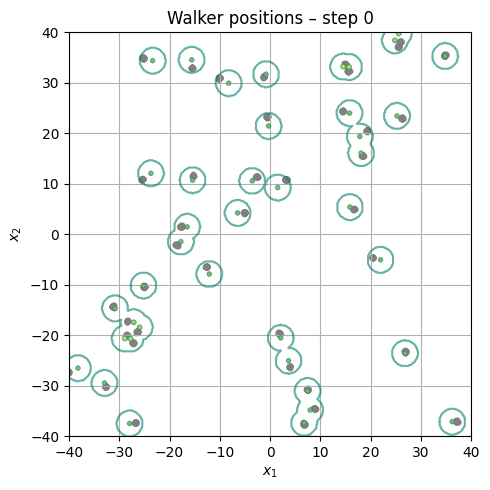

Step     0 | err 1779.9392 | loss 538.9429 | ESS 0.9861 | w.mean 0.01573 | w.std 0.08319


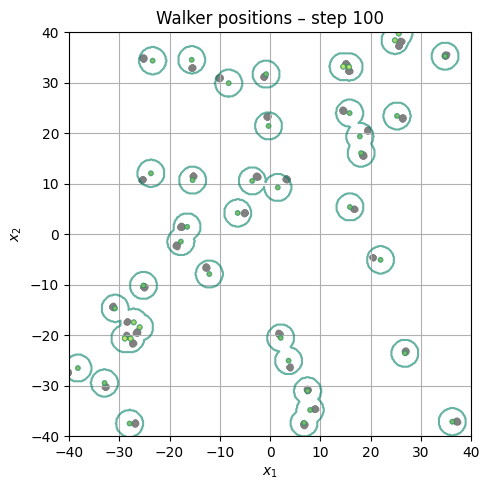

Step   100 | err 517.5800 | loss 171.9901 | ESS 0.9875 | w.mean 0.03834 | w.std 0.08934


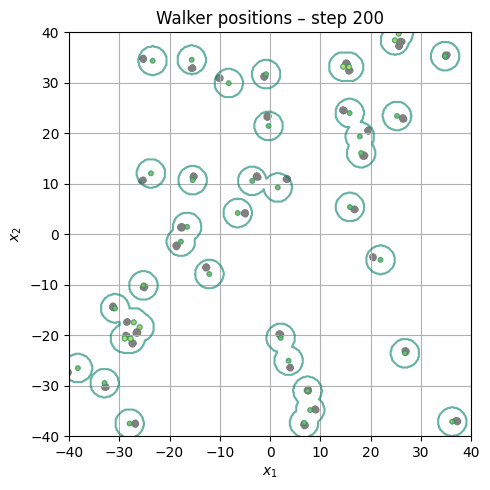

Step   200 | err 390.2810 | loss 178.8662 | ESS 0.9906 | w.mean 0.02898 | w.std 0.07656


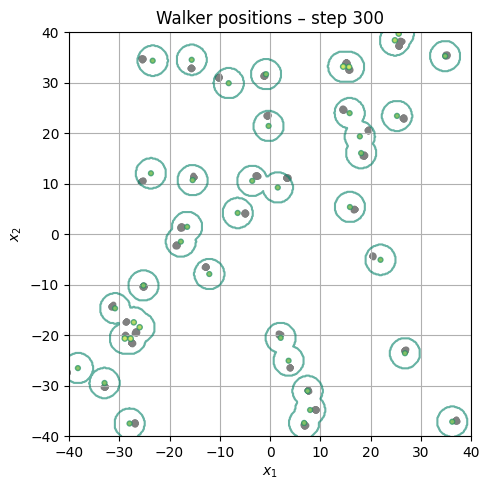

Step   300 | err 346.3111 | loss 197.4837 | ESS 0.9938 | w.mean 0.01622 | w.std 0.05870


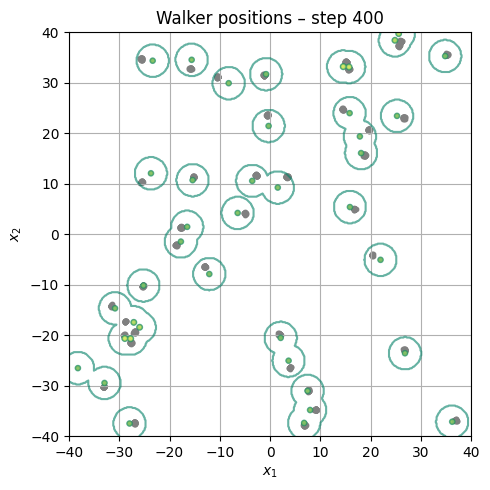

Step   400 | err 340.8544 | loss 189.9172 | ESS 0.9955 | w.mean 0.01081 | w.std 0.04776


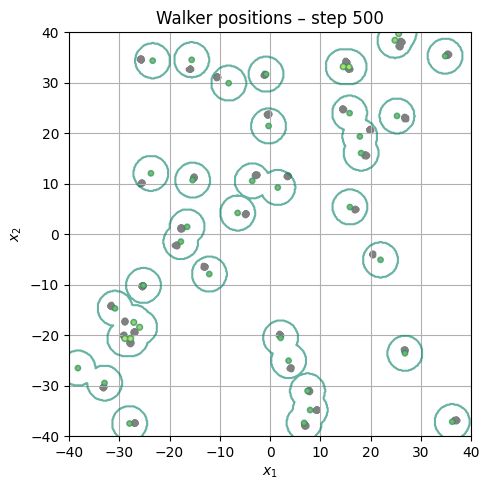

Step   500 | err 505.2453 | loss 178.8027 | ESS 0.9955 | w.mean 0.00829 | w.std 0.04626


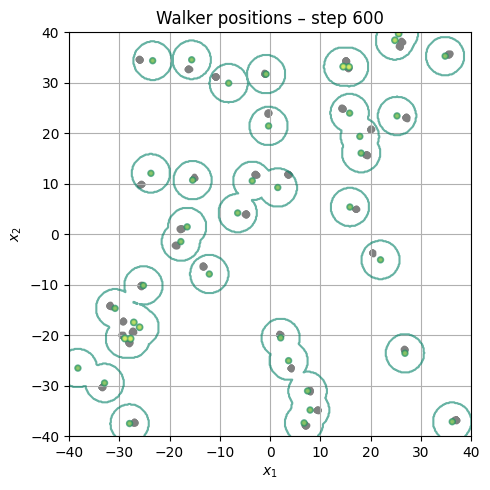

Step   600 | err 761.3137 | loss 176.7330 | ESS 0.9956 | w.mean 0.00625 | w.std 0.04452


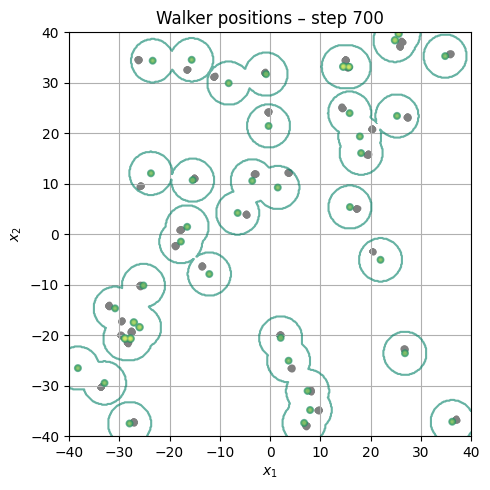

Step   700 | err 1430.8905 | loss 168.0007 | ESS 0.9961 | w.mean 0.00543 | w.std 0.04136


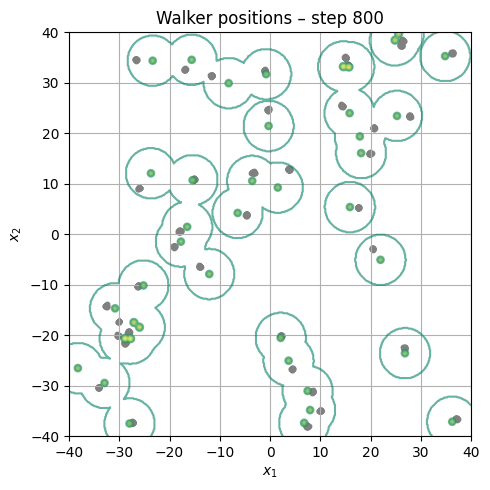

Step   800 | err 3306.5747 | loss 198.9877 | ESS 0.9966 | w.mean 0.00319 | w.std 0.03727


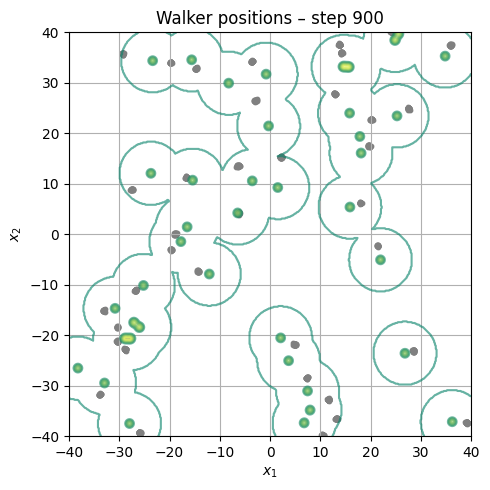

Step   900 | err 24703.5664 | loss 22639.0254 | ESS 0.9971 | w.mean 0.00101 | w.std 0.03162
-------------------------------------------------



In [24]:
torch.manual_seed(40)

dims = [2]
num_components_list = [40]
U_net = None
means = None
modes = not None


for dim in dims:
    for num_components in num_components_list:
        print(f'working on the {dim} dimensional {num_components} modes gmm')
        if num_components == 40:
            mixture = create_gaussian_mixture(dim, num_components, means=means_40, device=device)
        else:
            mixture = create_gaussian_mixture(dim, num_components, device=device)
        means_ = mixture.component_distribution.mean
        if means is not None:
            means = means_
        elif modes is not None:
            modes = means_
            # modes = modes + 1*torch.randn(num_components, dim).to(device)
        prior = prior(modes, num_samples=1000, device=device)
        train_and_save(dim, num_components, mixture=mixture, means=means, U_net=U_net, modes=modes, device=device, prior=prior)
        print('-------------------------------------------------\n')

<!-- # Evaluation -->

<!-- ## Hyper parameters for samplers -->

In [468]:
epsilon = 0
n_steps = 250
T = 1
dt = T / n_steps
num_samples = 2000
means = None
U_net = None
modes = not None
dim = 2
num_components = 10

<!-- ## Load the models and the mixture -->

In [469]:
drift = DriftNet(dim).to(device)
free_energy = FreeEnergyNet(dim).to(device)
if U_net is not None:
    U_net = PotentialNet(dim).to(device)
    load_dir = f'/Users/dilumfernando/projects/NETs/learned_interpolation/{dim}d_{num_components}gmm'
elif means is not None:
    load_dir = f'/Users/dilumfernando/projects/NETs/mean_interpolation/{dim}d_{num_components}gmm'
elif modes is not None:
    load_dir = f'/Users/dilumfernando/projects/NETs/alps_interpolation/{dim}d_{num_components}gmm'
else:
    load_dir = f'/Users/dilumfernando/projects/NETs/fixed_interpolation/{dim}d_{num_components}gmm'

In [470]:
if means is not None:
    print('loading with means')
    drift_path = os.path.join(load_dir, 'final_drift_means.pth')
    drift.load_state_dict(torch.load(drift_path, weights_only=True))
    drift.eval()

    free_path = os.path.join(load_dir, 'final_free_energy_means.pth')
    free_energy.load_state_dict(torch.load(free_path, weights_only=True))
    free_energy.eval()

    # Load from file
    mixture_path = os.path.join(load_dir, 'mixture.pth')
    params = torch.load(mixture_path)

    # Recreate the mixture
    mixture = create_gaussian_mixture(
        dimension=params['dim'],
        num_components=params['num_components'],
        means=params['means'],
        device=device
    )
    means = mixture.component_distribution.mean.requires_grad_(True)
    print(means.device)

elif modes is not None:
    print('loading with modes')
    drift_path = os.path.join(load_dir, 'final_drift_alps.pth')
    drift.load_state_dict(torch.load(drift_path, weights_only=True))
    drift.eval()

    free_path = os.path.join(load_dir, 'final_free_energy_alps.pth')
    free_energy.load_state_dict(torch.load(free_path, weights_only=True))
    free_energy.eval()

    # Load from file
    mixture_path = os.path.join(load_dir, 'mixture.pth')
    params = torch.load(mixture_path)

    # Recreate the mixture
    mixture = create_gaussian_mixture(
        dimension=params['dim'],
        num_components=params['num_components'],
        means=params['means'],
        device=device
    )
    means = mixture.component_distribution.mean.requires_grad_(True)
    modes = means
    print(means.device)
    
else:
    print('loading without means')
    drift_path = os.path.join(load_dir, 'final_drift.pth')
    drift.load_state_dict(torch.load(drift_path, weights_only=True))
    drift.eval()

    free_path = os.path.join(load_dir, 'final_free_energy.pth')
    free_energy.load_state_dict(torch.load(free_path, weights_only=True))
    free_energy.eval()
    if U_net is not None:
        potential_path = os.path.join(load_dir, 'final_potential.pth')
        U_net.load_state_dict(torch.load(potential_path, weights_only=True))
        U_net.eval()
        print('loaded the potential network too')

    # Load from file
    mixture_path = os.path.join(load_dir, 'mixture.pth')
    params = torch.load(mixture_path)

    # Recreate the mixture
    mixture = create_gaussian_mixture(
        dimension=params['dim'],
        num_components=params['num_components'],
        means=params['means'],
        device=device
    )

    means = mixture.component_distribution.mean.requires_grad_(True)


loading with modes
cpu


/var/folders/w4/41t2jw2j3_5gpty_15fgbksm0000gn/T/ipykernel_17426/3022726952.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  params = torch.load(mixture_path)


In [471]:
means, modes

(tensor([[-2.1139,  5.8576],
         [-5.2207,  3.4513],
         [ 5.8389, -0.1959],
         [ 0.8020, -5.8909],
         [-3.3640, -6.8693],
         [ 4.8248, -2.8091],
         [ 4.1325,  6.2332],
         [ 3.1348, -0.3047],
         [ 5.6723, -6.1923],
         [ 2.8458, -7.7229]], requires_grad=True),
 tensor([[-2.1139,  5.8576],
         [-5.2207,  3.4513],
         [ 5.8389, -0.1959],
         [ 0.8020, -5.8909],
         [-3.3640, -6.8693],
         [ 4.8248, -2.8091],
         [ 4.1325,  6.2332],
         [ 3.1348, -0.3047],
         [ 5.6723, -6.1923],
         [ 2.8458, -7.7229]], requires_grad=True))

<!-- ## Annealed Importance Sampler -->

In [473]:
def langevin_sampler(x0, A0, dt, steps, epsilon, means, U_net, modes, mixture):
    x = x0.detach().requires_grad_(True)
    A = A0
    x_trajectory = [x0.detach().cpu()]  # list of (batch, 2)
    A_trajectory = [A.cpu()]

    for step in range(steps):
        t_tensor = torch.full((x.shape[0],), step * dt, device=device).requires_grad_(True)
        grad_U = grad_U_t(x, t_tensor, means, U_net, modes, mixture) # interpolating potential
        # dtU, _ = partial_t_U(x, t_tensor, means, U_net, modes)
        dtU = partial_t_U(x, t_tensor, means, U_net, modes, mixture)
        noise = torch.randn_like(x)
        x = x - epsilon * grad_U * dt + torch.sqrt(torch.tensor(2 * epsilon * dt)) * noise
        A = A - dtU * dt

        x_trajectory.append(x.detach().cpu())
        A_trajectory.append(A.detach().cpu())
        x = x.detach().requires_grad_(True)

    return torch.stack(x_trajectory), torch.stack(A_trajectory)  # (steps, batch, 2)


means_ = modes
K, dim = means_.shape
beta_max = torch.tensor(1e2, device=device).unsqueeze(0).expand(num_samples)         
means_prior = means_.unsqueeze(0).expand(num_samples, -1, -1) + 4*torch.randn(K, dim)
mix = create_gaussian_mixture(dim, K, means=means_prior.to(device), covs=1/beta_max)
x0 = mix.sample().to(device)
# x0 = torch.randn(num_samples, dim, device=device)

A0 = torch.zeros(num_samples, device=device)
x_langevin, A_langevin = langevin_sampler(x0, A0, dt = dt, steps=n_steps, epsilon=1, 
                                          means=None, U_net=U_net, modes=modes, mixture=mixture)
ess_langevin = ess_eval(A_langevin)
print(ess_langevin)

tensor([1.0000, 0.8254, 0.5856, 0.4373, 0.3520, 0.3008, 0.2681, 0.2462, 0.2302,
        0.2187, 0.2096, 0.2028, 0.1973, 0.1930, 0.1894, 0.1867, 0.1843, 0.1823,
        0.1806, 0.1790, 0.1778, 0.1767, 0.1756, 0.1747, 0.1736, 0.1730, 0.1725,
        0.1722, 0.1721, 0.1719, 0.1716, 0.1714, 0.1711, 0.1710, 0.1710, 0.1710,
        0.1708, 0.1706, 0.1706, 0.1707, 0.1708, 0.1708, 0.1707, 0.1708, 0.1708,
        0.1709, 0.1709, 0.1710, 0.1712, 0.1714, 0.1715, 0.1717, 0.1718, 0.1719,
        0.1721, 0.1722, 0.1724, 0.1725, 0.1725, 0.1726, 0.1726, 0.1726, 0.1727,
        0.1726, 0.1726, 0.1725, 0.1725, 0.1726, 0.1726, 0.1728, 0.1728, 0.1729,
        0.1730, 0.1730, 0.1732, 0.1733, 0.1734, 0.1735, 0.1736, 0.1736, 0.1737,
        0.1737, 0.1737, 0.1737, 0.1736, 0.1736, 0.1736, 0.1737, 0.1737, 0.1739,
        0.1739, 0.1739, 0.1739, 0.1739, 0.1741, 0.1741, 0.1741, 0.1742, 0.1743,
        0.1743, 0.1743, 0.1743, 0.1743, 0.1744, 0.1743, 0.1741, 0.1739, 0.1738,
        0.1735, 0.1733, 0.1731, 0.1730, 

In [474]:
def plot_annealed_langevin(means, modes, mixture, device):
    # 6. Set up plot and animation
    size = 20
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(-size, size)
    ax.set_ylim(-size, size)
    ax.set_aspect('equal')
    ax.set_title("Annealed Langevin Dynamics")
    ax.grid(True)

    # Create a 2D grid
    x = torch.linspace(-size, size, 500, device=device)
    y = torch.linspace(-size, size, 500, device=device)
    X, Y = torch.meshgrid(x, y, indexing='xy')
    grid = torch.stack([X.flatten(), Y.flatten()], dim=-1)

    # Precompute contour levels once (fix levels for stability)
    levels = 10
    def update(frame):
        ax.clear()
        t_tensor = torch.full((grid.shape[0],), frame * dt, device=grid.device)
        p_vals = p_t(grid, t_tensor, None, U_net, modes, mixture).reshape(500, 500)
        ax.contour(X.cpu().numpy(), Y.cpu().numpy(), p_vals.detach().cpu().numpy(), levels=levels, cmap='summer', alpha=0.5)
        ax.scatter(x_langevin[frame][:, 0].cpu(), x_langevin[frame][:, 1].cpu(),
                s=30, color='grey', alpha=1.0)
        ax.set_xlim(-size, size)
        ax.set_ylim(-size, size) 
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title(f"Annealed Langevin Dynamics, time={t_tensor[0] + dt:.2f}")


    anim = FuncAnimation(fig, update, frames=n_steps, interval=100)

    # To save as GIF uncomment:
    gif_path = os.path.join(load_dir, 'ALD_modes_eps1.gif')
    # gif_path = os.path.join(load_dir, 'density.gif')
    anim.save(gif_path, writer=PillowWriter(fps=60))

    plt.show()

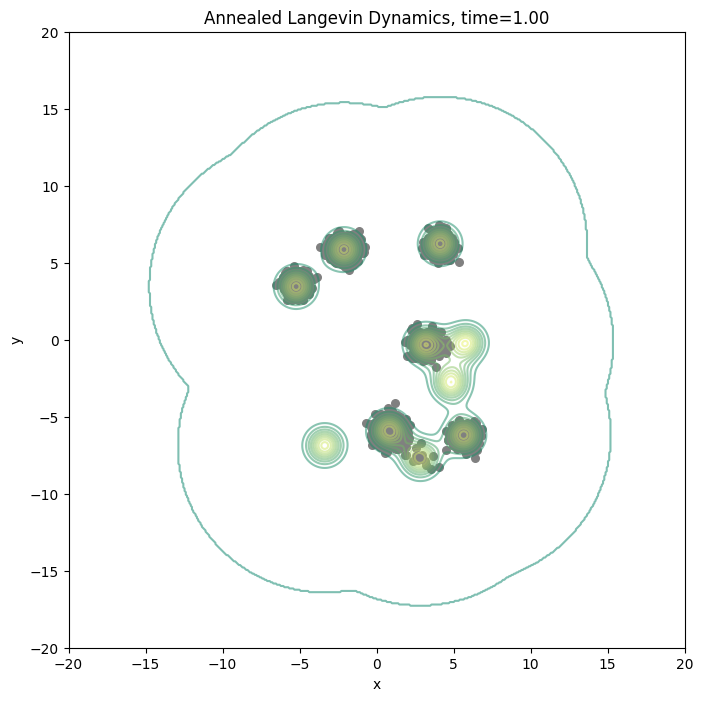

In [475]:
plot_annealed_langevin(means, modes, mixture, device)

<!-- ## NET sampler -->

In [476]:
def NET_Sampler(drift, x0, A0, dt, steps, epsilon, means, U_net, modes, mixture):
    x = x0.detach().requires_grad_(True)
    A = A0.detach().requires_grad_(True)
    x_trajectory = [x0.detach().cpu()]  # list of (batch, 2)
    A_trajectory = [A0.detach().cpu()]
    
    for step in range(steps+1):
        noise = torch.randn_like(x)
        t_tensor = torch.full((x.shape[0],), step * dt, device=device).requires_grad_(True)

        b = drift(x, t_tensor)
        grad_U = grad_U_t(x, t_tensor, means, U_net, modes, mixture)
        # dtU, _ = partial_t_U(x, t_tensor, means, U_net, modes)
        dtU = partial_t_U(x, t_tensor, means, U_net, modes, mixture)
        div_b = divergence(b, x)
        
        x = x - epsilon * grad_U * dt + b * dt + (2 * epsilon * dt) ** 0.5 * noise
        A = A + div_b * dt - dtU * dt - (b * grad_U).sum(dim=1) * dt 

        x_trajectory.append(x.detach().cpu())
        A_trajectory.append(A.detach().cpu())
        x = x.detach().requires_grad_(True)
    
    return torch.stack(x_trajectory), torch.stack(A_trajectory)



In [477]:
# x0 = torch.randn(num_samples, dim, device=device)
A0 = torch.zeros(num_samples, device=device)
x_nets, A_nets = NET_Sampler(drift, x0, A0, dt = dt, steps=n_steps, epsilon=1, 
                             means=None, U_net=U_net, modes=means, mixture=mixture)
ess_nets = ess_eval(A_nets)
print(ess_nets)

tensor([1.0000e+00, 5.4380e-01, 2.4931e-01, 1.6117e-01, 1.2569e-01, 1.0704e-01,
        9.4918e-02, 8.5004e-02, 7.7068e-02, 6.8797e-02, 5.9124e-02, 5.1339e-02,
        4.3897e-02, 3.8327e-02, 3.3592e-02, 2.9270e-02, 2.4618e-02, 2.1211e-02,
        1.7795e-02, 1.4262e-02, 1.0122e-02, 8.2455e-03, 6.9838e-03, 6.0164e-03,
        5.4278e-03, 4.9714e-03, 4.8060e-03, 4.3399e-03, 3.8511e-03, 3.4796e-03,
        2.9196e-03, 2.6567e-03, 2.5716e-03, 2.5240e-03, 2.5044e-03, 2.2827e-03,
        2.0761e-03, 1.8996e-03, 1.6548e-03, 1.4983e-03, 1.3726e-03, 1.3042e-03,
        1.2993e-03, 1.2928e-03, 1.3176e-03, 1.3544e-03, 1.3580e-03, 1.3371e-03,
        1.2996e-03, 1.2884e-03, 1.2868e-03, 1.2655e-03, 1.2013e-03, 1.1776e-03,
        1.1493e-03, 1.1349e-03, 1.1334e-03, 1.1070e-03, 1.0499e-03, 1.0034e-03,
        9.7488e-04, 9.7128e-04, 9.6060e-04, 9.4284e-04, 9.2775e-04, 9.0506e-04,
        8.5989e-04, 8.3562e-04, 8.0909e-04, 7.9696e-04, 8.0392e-04, 8.0063e-04,
        7.9663e-04, 8.0019e-04, 8.0816e-

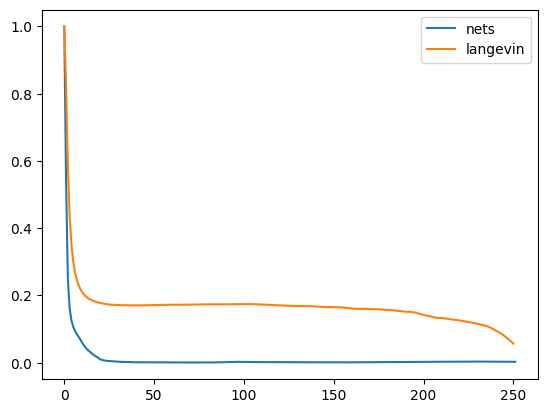

In [478]:
plt.plot(ess_nets, label='nets')
plt.plot(ess_langevin, label='langevin')
plt.legend()
plt.show()

In [481]:
def plot_nets(means):
    # Create a 2D grid
    device=means.device
    size = 20
    x = torch.linspace(-size, size, 500, device=device)
    y = torch.linspace(-size, size, 500, device=device)
    X, Y = torch.meshgrid(x, y, indexing='xy')
    grid = torch.stack([X.flatten(), Y.flatten()], dim=-1)

    # # Compute density
    # with torch.no_grad():
    #     Z = mixture.log_prob(grid).exp().reshape(500, 500)

    # init_Z = torch.zeros((500, 500))

    # 6. Set up plot and animation
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(-size, size)
    ax.set_ylim(-size, size)
    ax.set_aspect('equal')
    ax.set_title("NETS Dynamics")
    ax.grid(True)

    levels = 10

    def update(frame):
        ax.clear()
        t_tensor = torch.full((grid.shape[0],), frame * dt, device=device)
        # ax.scatter(means_[:, 0].detach().numpy(), means_[:, 1].detach().numpy(), marker='x', color='red')
        p_vals = p_t(grid, t_tensor, None, U_net, means, mixture).reshape(500, 500)
        ax.contour(X.numpy(), Y.numpy(), p_vals.detach().numpy(), levels=levels, cmap='summer', alpha=0.5)
        ax.scatter(x_nets[frame][:, 0], x_nets[frame][:, 1],
                s=30, color='grey', alpha=1.0)
        ax.set_xlim(-size, size)
        ax.set_ylim(-size, size) 
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title(f"NETS Dynamics, time={t_tensor[0]+dt:.2f}")


    anim = FuncAnimation(fig, update, frames=n_steps, interval=100)

    # To save as GIF uncomment:
    gif_path = os.path.join(load_dir, 'nets_dynamics_eps1.gif')
    anim.save(gif_path, writer=PillowWriter(fps=60))

    plt.show()

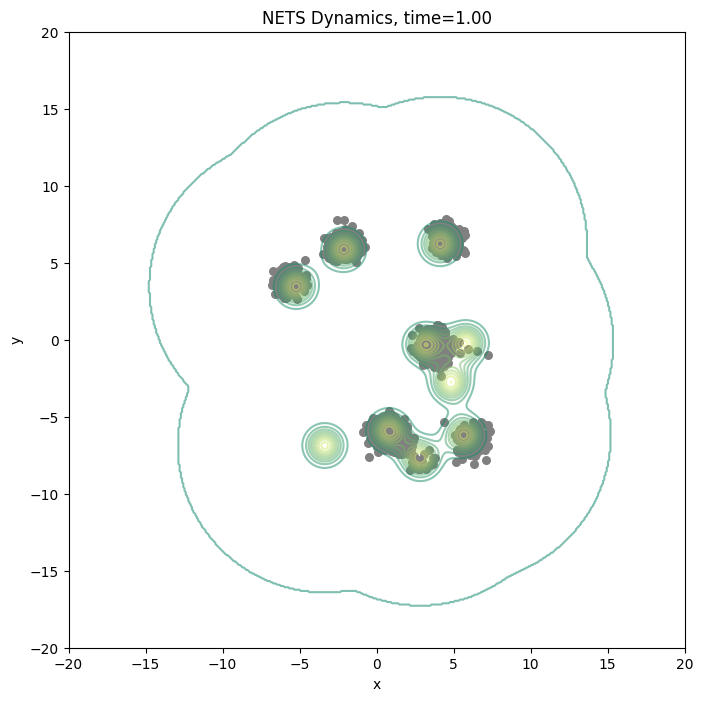

In [482]:
plot_nets(modes)

## ALDP Runner

Use these cells to launch the Alanine dipeptide training script from this notebook through the dedicated `pita-aldp` environment.

In [ ]:
from pathlib import Path
import os
import subprocess


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "Training" / "run_training.py").exists() and (candidate / "conf").exists():
            return candidate
    raise RuntimeError("Could not locate the NETS repo root from the notebook working directory.")


REPO_ROOT = find_repo_root()
ALDP_PYTHON = Path("/opt/homebrew/anaconda3/envs/pita-aldp/bin/python")
if not ALDP_PYTHON.exists():
    raise FileNotFoundError(f"Expected ALDP environment python at {ALDP_PYTHON}")

ALDP_ENV = os.environ.copy()
ALDP_ENV.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")
ALDP_ENV.setdefault("XDG_CACHE_HOME", "/tmp")
ALDP_ENV["MPLBACKEND"] = "Agg"
ALDP_ENV.setdefault("LOKY_MAX_CPU_COUNT", "8")

print("Repo root:", REPO_ROOT)
print("ALDP python:", ALDP_PYTHON)

In [ ]:
def run_aldp_training(*extra_overrides: str) -> None:
    cmd = [
        str(ALDP_PYTHON),
        "Training/run_training.py",
        "experiment=alps_aldp",
        *extra_overrides,
    ]
    print("Running:", " ".join(cmd))
    completed = subprocess.run(cmd, cwd=REPO_ROOT, env=ALDP_ENV, text=True)
    if completed.returncode != 0:
        raise RuntimeError(f"ALDP training failed with exit code {completed.returncode}")

In [ ]:
# Quick smoke test
run_aldp_training(
    "training.steps=2",
    "training.n_walkers=64",
    "data.true_sample_count=64",
)

In [ ]:
def run_aldp_eval(*extra_overrides: str) -> None:
    cmd = [
        str(ALDP_PYTHON),
        "Testing/run_eval.py",
        "experiment=alps_aldp",
        *extra_overrides,
    ]
    print("Running:", " ".join(cmd))
    completed = subprocess.run(cmd, cwd=REPO_ROOT, env=ALDP_ENV, text=True)
    if completed.returncode != 0:
        raise RuntimeError(f"ALDP eval failed with exit code {completed.returncode}")


def run_aldp_tica_plot(*extra_overrides: str) -> None:
    cmd = [
        str(ALDP_PYTHON),
        "Testing/run_aldp_tica.py",
        "experiment=alps_aldp",
        *extra_overrides,
    ]
    print("Running:", " ".join(cmd))
    completed = subprocess.run(cmd, cwd=REPO_ROOT, env=ALDP_ENV, text=True)
    if completed.returncode != 0:
        raise RuntimeError(f"ALDP TICA plotting failed with exit code {completed.returncode}")

In [ ]:
# After training succeeds, generate samples and save eval artifacts
run_aldp_eval(
    "eval.num_samples=512",
    "eval.true_sample_count=512",
    "eval.steps=50",
    "eval.plot_every=0",
)

In [ ]:
# Then create the TICA comparison plot of generated vs true samples
run_aldp_tica_plot()